# Unsupervised Learning

In this field, we work with unlabeled data. While in supervised learning we try to generalize the data based on given target data, in unsupervised learning we create our own labels.

## Clustering

Cluster - group of nearly placed instances

### K-means

This algorithm works by defining centroids of clusters.


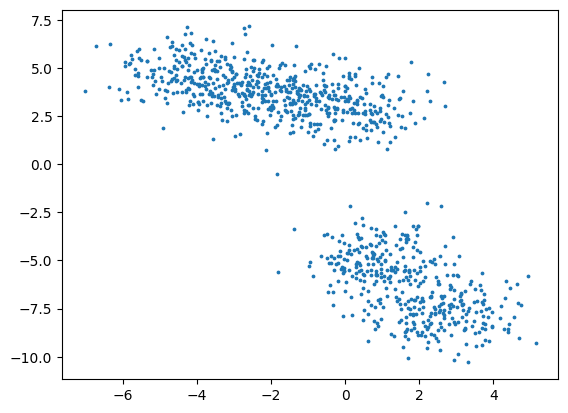

In [79]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=5)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

In [80]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
kmeans.labels_[:10]

array([4, 2, 3, 1, 2, 2, 4, 1, 3, 2], dtype=int32)

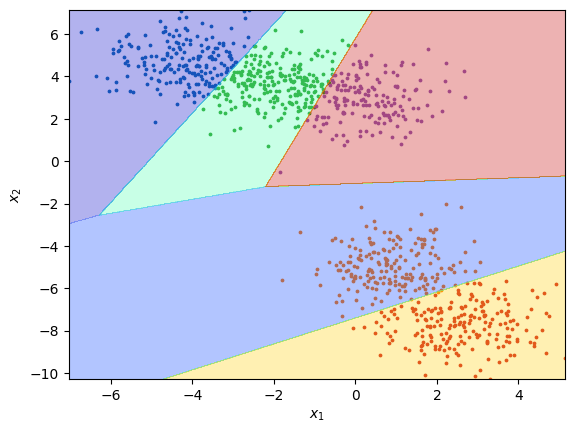

In [102]:
import numpy as np

def plot_2d_scatter_and_centers(X: np.typing.NDArray, resolution: int = 1000,  centers: np.typing.NDArray | None = None) -> None:
    for i in range(k):
        plt.scatter(X[:, 0][y_pred == i], X[:, 1][y_pred == i], s=3)

    X_mins = X.min(axis=0)
    X_maxs = X.max(axis=0)


    xx, yy = np.meshgrid(
        np.linspace(X_mins[0], X_maxs[0], resolution),
        np.linspace(X_mins[1], X_maxs[1], resolution)
    )

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, alpha=0.3, extent=(X_mins[0], X_maxs[0], X_mins[1], X_maxs[1]), cmap="jet")

    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="*", s=100, c="black")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")

    plt.show()

plot_2d_scatter_and_centers(X)

In [103]:
kmeans.cluster_centers_

array([[-4.25626959,  4.72306919],
       [ 0.879845  , -4.92397943],
       [-1.94109334,  3.62422534],
       [ 2.61149236, -7.75228306],
       [ 0.34724109,  2.90260211]])

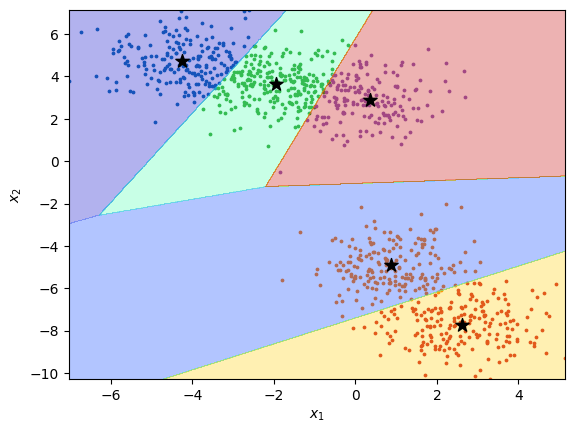

In [111]:
plot_2d_scatter_and_centers(X, 1000, kmeans.cluster_centers_)